# Trench bending moment, neutral plane, and the elastic-plate comparison (Fluidity)

**Position in the project.** The Fluidity twin of `trench_pull_mdoodz/model_analysis/bending_moment.ipynb`, and the flexural companion to `fluidity_centroid_arm.ipynb`. The two resultants that control the trench deflection are the **vertical shear resultant** $V$ at the trench and the **bending moment** $M$; both are measured directly from the stress field, then the observed deflection $w_T$ is tested against a **broken elastic plate** carrying the same $(V, M)$. Unlike the forced MDOODZ model — whose trench turns out to be almost purely moment-supported — the free-subduction trench here carries a genuine vertical load, and plate strength can evolve over the 80 Myr run, which is exactly what the elastic comparison is designed to expose.

**Definitions.** Fibre stress $\Delta\sigma(z) = \sigma_{xx} - \sigma_{zz}$ (the $N_D$ integrand); bending moment about the neutral plane

$$M(x) = \int \Delta\sigma(z)\,(z - z_{np})\,dz$$

over the mechanical plate. With $z$ positive down, the trench bending sense (extension above the neutral plane, compression below) makes $M < 0$; magnitudes are quoted as $|M|$.

**Robust neutral plane.** $\Delta\sigma(z)$ can have several zero crossings, so a first-crossing picker is fragile (the legacy §8 pick in `fluidity_single_step.ipynb` even carries a hard-coded 30 km fallback). Instead: $z_{np}$ is taken at the **extremum of the cumulative fibre stress** $C(z) = \int_0^z \Delta\sigma\,dz'$ — an extremum of $C$ *is* a crossing of $\Delta\sigma$, and automatically the one separating the dominant extension and compression lobes. The first-crossing pick is computed alongside for comparison.

**Pivot caveat.** $dM/dz_{\mathrm{pivot}} = -N_D$; the sensitivity is printed, not assumed.

## 1. Setup

Extraction identical to `fluidity_centroid_arm.ipynb`: pvtu sampled to a regular grid (200 m for the single step, 1 km for the time loop), off-diagonal sign flip at extraction, x-mirror to the MDOODZ orientation. Honesty: **neutral-plane search 5–60 km; plate base at the 950 °C isotherm capped at 65 km; $M$ integrated from the local free surface to that base.**

In [1]:
import sys, glob
from pathlib import Path

import numpy as np
import natsort
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import brentq

_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)
from cerpa_helpers import make_field_extractor, mirror_fields_in_x, pick_trench_3step

DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'
MODELS = {'STD': 'STD_RefModel', 'WAL': 'WAL_RefModel'}
MODEL_KEY      = 'WAL'    # single-step model
TIMESTEP_INDEX = 10
SECONDS_PER_YEAR = 31_557_600.0

DX_SS = 200.0             # single-step grid [m]
DX_TS = 1000.0            # time-loop grid [m]
Z_MAX = 75_000.0
Y_SURFACE = 2_900_000.0
SUBDUCTING_SIDE, SEAWARD_SIGN = "right", +1

G = 9.8
DRHO = 3300.0             # rho_m - rho_w (no water)
T_BASE_C   = 950.0        # mechanical base isotherm (report!)
Z_BASE_CAP = 65e3
NP_ZMIN, NP_ZMAX = 5e3, 60e3     # neutral-plane search window (report!)

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
outputs_dir = Path('outputs'); outputs_dir.mkdir(exist_ok=True)

# brand colours (STD navy, WAL magenta)
MCOL = {"STD": "#002147", "WAL": "#E5007D"}

def load_snapshot(ff, DX):
    d = pv.read(ff)
    try:
        t_myr = float(np.asarray(d["NormalSP::Time"]).ravel()[0]) / SECONDS_PER_YEAR / 1e6
    except Exception:
        t_myr = np.nan
    d.point_data["p"]   = d["NormalSP::Pressure"]
    d.point_data["txx"] = d["NormalSP::Stress"][:, 0]
    d.point_data["tzz"] = d["NormalSP::Stress"][:, 4]
    d.point_data["txz"] = -d["NormalSP::Stress"][:, 1]
    d.point_data["T"]   = d["NormalSP::Temperature"]
    d.point_data["fs"]  = d["NormalSP::FreeSurface"]
    d.point_data["vx"]  = d["NormalSP::Velocity"][:, 0]
    d.point_data["vy"]  = d["NormalSP::Velocity"][:, 1]
    x_min, x_max, *_ = d.bounds
    nx, nz = int((x_max - x_min) / DX), int(Z_MAX / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing="xy")
    grid = pv.StructuredGrid(X.T, (Y_SURFACE - Z).T, np.zeros_like(X.T))
    interp = grid.sample(d)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)
    gf = make_field_extractor(interp, nx_pv, nz_pv, valid)
    p, txx, tzz, txz = gf("p"), gf("txx"), gf("tzz"), gf("txz")
    T, fs, vx, vz = gf("T"), gf("fs"), gf("vx"), -gf("vy")
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    sigma_zz = np.nan_to_num(-p + tzz)
    sigma_xx = np.nan_to_num(-p + txx)
    tau_zx = np.nan_to_num(txz)
    fs_top = fs[0, :].copy()
    for j in np.where(np.isnan(fs_top))[0]:
        k = np.where(np.isfinite(fs[:, j]))[0]
        fs_top[j] = fs[k[0], j] if len(k) else 0.0
    return t_myr, x, z, sigma_xx, sigma_zz, tau_zx, np.nan_to_num(T), fs_top, p, vx

def key_columns(x, z, tau_zx, fs_top, p, vx, DX):
    x_trench, _ = pick_trench_3step(x, z, p, vx, vx_depth_m=5000, Wp1_km=1000,
                                    Wv_km=800, Wp3_km=800, smooth_km=40,
                                    subducting_side=SUBDUCTING_SIDE)
    ti = int(np.argmin(np.abs(x - x_trench)))
    V = np.trapz(tau_zx, z, axis=0)
    dVdx = np.gradient(gaussian_filter1d(V, max(1, int(10e3 / DX))), x)
    i = ti + int(10e3 / DX)
    s0 = np.sign(dVdx[i])
    while np.sign(dVdx[i]) == s0 and x[i] < x[ti] + 400e3:
        i += 1
    iI = i
    ib = ti + int(np.argmax(fs_top[ti:iI + int(200e3 / DX)]))
    return ti, iI, ib, V

def neutral_plane_and_moment(z, dsig_col, z_surf_j, z_base_j):
    zm = (z >= max(z_surf_j, 0.0)) & (z <= z_base_j)
    zw = z[zm]; ds = dsig_col[zm]
    if len(zw) < 5:
        return None
    C = np.concatenate([[0.0], np.cumsum(0.5 * (ds[1:] + ds[:-1]) * np.diff(zw))])
    sw = (zw >= NP_ZMIN) & (zw <= min(NP_ZMAX, z_base_j))
    if not sw.any():
        return None
    k = np.where(sw)[0][int(np.argmax(np.abs(C[sw])))]
    z_np = zw[k]
    for kk in (k - 1, k):
        if 0 <= kk < len(zw) - 1 and ds[kk] * ds[kk + 1] < 0:
            z_np = zw[kk] - ds[kk] * (zw[kk + 1] - zw[kk]) / (ds[kk + 1] - ds[kk])
            break
    lw = (zw >= 10e3) & (zw <= 50e3)
    zl, dl = zw[lw], ds[lw]
    scs = np.where(dl[:-1] * dl[1:] < 0)[0]
    z_np_first = np.nan
    if len(scs):
        kk = scs[0]
        z_np_first = zl[kk] - dl[kk] * (zl[kk + 1] - zl[kk]) / (dl[kk + 1] - dl[kk])
    return dict(z_np=z_np, z_np_first=z_np_first, n_cross=len(scs),
                M=np.trapz(ds * (zw - z_np), zw), N=np.trapz(ds, zw),
                zw=zw, ds=ds, C=C)

## 2. Single step — neutral plane and $M(x)$ (WAL, f10)

Same panel logic as the MDOODZ notebook: (a) fibre-stress profile at the trench with both neutral-plane picks; (b) the cumulative $C(z)$ whose extremum defines the robust pick; (c) $M(x)$ with local and fixed pivots; (d) the flexure identity $V = dM/dx$ against the independently extracted $V(x)$.

In [2]:
pvtu_files = natsort.natsorted(glob.glob(DATA_ROOT + MODELS[MODEL_KEY] + '/subduction_with_LM*.pvtu'))
ff = pvtu_files[TIMESTEP_INDEX]
t_myr, x, z, sigma_xx, sigma_zz, tau_zx, T, fs_top, p, vx = load_snapshot(ff, DX_SS)
ti, iI, ib, V = key_columns(x, z, tau_zx, fs_top, p, vx, DX_SS)
w = fs_top[iI] - fs_top
z_surf = -fs_top
z_base = np.array([z[np.argmax(T[:, j] > (T_BASE_C + 273.15))] for j in range(len(x))])
z_base = np.minimum(z_base, Z_BASE_CAP)
dsig = sigma_xx - sigma_zz

r = neutral_plane_and_moment(z, dsig[:, ti], z_surf[ti], z_base[ti])
print(f"{MODELS[MODEL_KEY]} f{TIMESTEP_INDEX}, t = {t_myr:.1f} Myr")
print(f"x_T = {x[ti]/1e3:.0f} km, x_b = {x[ib]/1e3:.0f}, x_I = {x[iI]/1e3:.0f} km; w_T = {w[ti]:.0f} m")
print(f"z_np(extremum) = {r['z_np']/1e3:.1f} km, z_np(first crossing) = "
      f"{r['z_np_first']/1e3:.1f} km, crossings in [10,50] km: {r['n_cross']}")
print(f"M_T = {r['M']*1e-17:+.3f} x 10^17 N (about z_np; negative = trench bending sense)")
print(f"N_D(x_T) = {r['N']*1e-12:+.2f} TN/m -> pivot sensitivity "
      f"{abs(r['N'])*5e3*1e-17:.3f} x 10^17 N per 5 km of pivot")
print(f"V_T = {V[ti]*1e-12:+.2f} TN/m (extracted sense)")

sea = slice(ti, iI + (iI - ti))
z_np_x = np.full(len(x), np.nan)
M_x = np.full(len(x), np.nan)
Mfix_x = np.full(len(x), np.nan)
for j in range(sea.start, sea.stop):
    rj = neutral_plane_and_moment(z, dsig[:, j], z_surf[j], z_base[j])
    if rj is None:
        continue
    z_np_x[j] = rj["z_np"]; M_x[j] = rj["M"]
    zm = (z >= z_surf[j]) & (z <= z_base[j])
    Mfix_x[j] = np.trapz(dsig[zm, j] * (z[zm] - r["z_np"]), z[zm])
dMdx = np.gradient(gaussian_filter1d(np.nan_to_num(Mfix_x), int(3e3 / DX_SS)), x)
seaJ = slice(ti + int(3e3 / DX_SS), iI)
cc = np.corrcoef(dMdx[seaJ], V[seaJ])[0, 1]
print(f"flexure check: corr(dM/dx, V) over (x_T, x_I) = {cc:+.3f}")

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


...

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


/opt/anaconda3/envs/pyvista-env/lib/python3.12/site-packages/pyvista/core/utilities/fileio.py:308: UserWarning: The VTK reader `vtkXMLPUnstructuredGridReader` in pyvista reader `XMLPUnstructuredGridReader('/Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/subduction_with_LM_10.pvtu')` raised an error while reading the file.
	"Piece cell data array vtkGhostLevels not found"
  warnings.warn(


WAL_RefModel f10, t = 20.0 Myr
x_T = 4440 km, x_b = 4576, x_I = 4520 km; w_T = 1717 m
z_np(extremum) = 26.6 km, z_np(first crossing) = 26.6 km, crossings in [10,50] km: 1
M_T = -0.708 x 10^17 N (about z_np; negative = trench bending sense)
N_D(x_T) = -0.37 TN/m -> pivot sensitivity 0.019 x 10^17 N per 5 km of pivot
V_T = -1.08 TN/m (extracted sense)
flexure check: corr(dM/dx, V) over (x_T, x_I) = +0.787


figure: figures/bending_moment_ref_WAL_f10.png


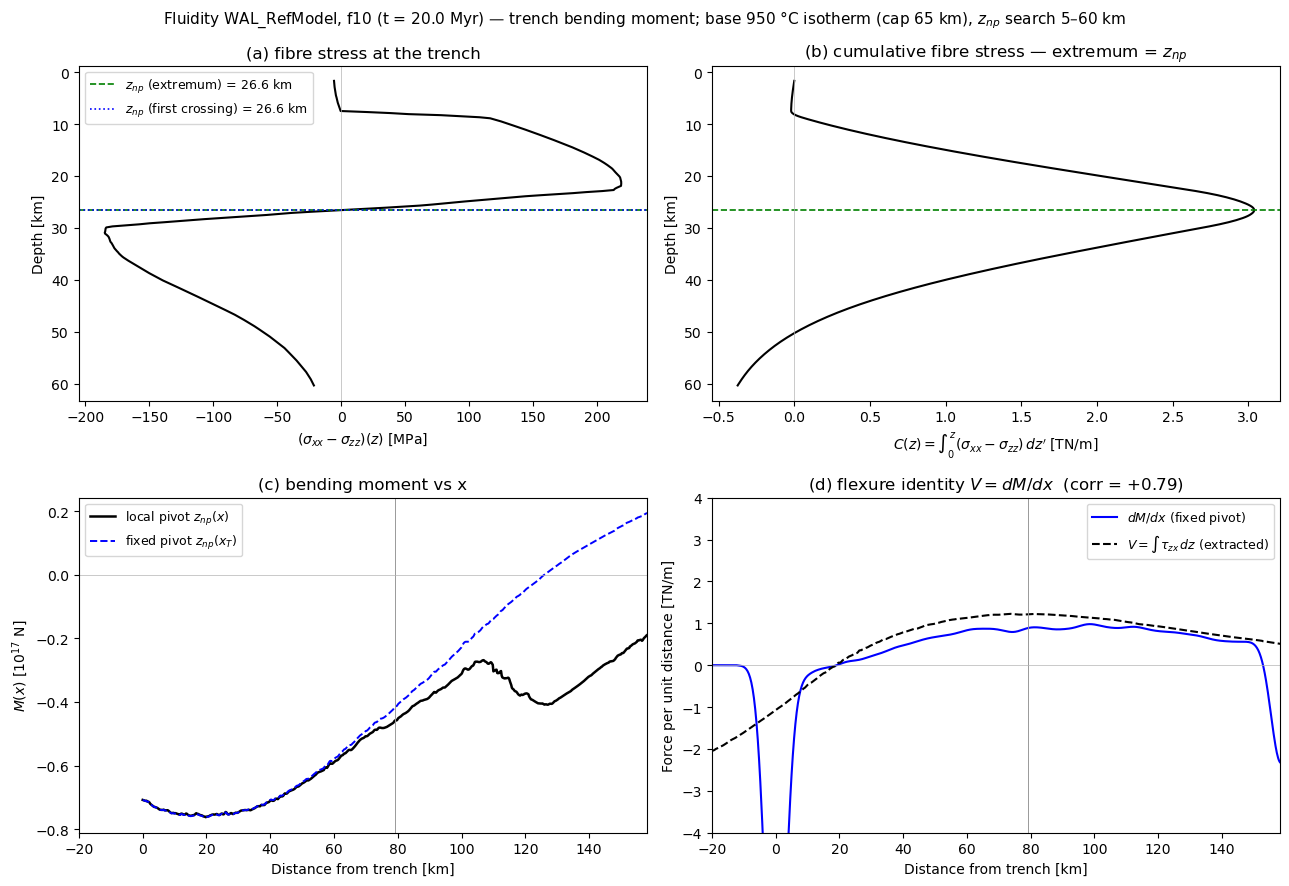

In [3]:
xkm = (x - x[ti]) / 1e3
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(r["ds"] * 1e-6, r["zw"] / 1e3, "k-", lw=1.5)
axes[0, 0].axhline(r["z_np"] / 1e3, color="g", ls="--", lw=1.2,
                   label=f"$z_{{np}}$ (extremum) = {r['z_np']/1e3:.1f} km")
if np.isfinite(r["z_np_first"]):
    axes[0, 0].axhline(r["z_np_first"] / 1e3, color="b", ls=":", lw=1.2,
                       label=f"$z_{{np}}$ (first crossing) = {r['z_np_first']/1e3:.1f} km")
axes[0, 0].axvline(0, color="0.7", lw=0.5)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel(r"$(\sigma_{xx}-\sigma_{zz})(z)$ [MPa]")
axes[0, 0].set_ylabel("Depth [km]")
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_title("(a) fibre stress at the trench")

axes[0, 1].plot(r["C"] * 1e-12, r["zw"] / 1e3, "k-", lw=1.5)
axes[0, 1].axhline(r["z_np"] / 1e3, color="g", ls="--", lw=1.2)
axes[0, 1].axvline(0, color="0.7", lw=0.5)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel(r"$C(z)=\int_0^z(\sigma_{xx}-\sigma_{zz})\,dz'$ [TN/m]")
axes[0, 1].set_ylabel("Depth [km]")
axes[0, 1].set_title("(b) cumulative fibre stress — extremum = $z_{np}$")

axes[1, 0].plot(xkm, M_x * 1e-17, "k-", lw=1.8, label="local pivot $z_{np}(x)$")
axes[1, 0].plot(xkm, Mfix_x * 1e-17, "b--", lw=1.4, label="fixed pivot $z_{np}(x_T)$")
axes[1, 0].axvline((x[iI] - x[ti]) / 1e3, color="0.6", lw=0.7)
axes[1, 0].axhline(0, color="0.7", lw=0.5)
axes[1, 0].set_xlim(-20, xkm[sea.stop - 1])
axes[1, 0].set_xlabel("Distance from trench [km]")
axes[1, 0].set_ylabel(r"$M(x)$ [$10^{17}$ N]")
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_title("(c) bending moment vs x")

axes[1, 1].plot(xkm, dMdx * 1e-12, "b-", lw=1.5, label=r"$dM/dx$ (fixed pivot)")
axes[1, 1].plot(xkm, V * 1e-12, "k--", lw=1.5, label=r"$V=\int\tau_{zx}\,dz$ (extracted)")
axes[1, 1].axvline((x[iI] - x[ti]) / 1e3, color="0.6", lw=0.7)
axes[1, 1].axhline(0, color="0.7", lw=0.5)
axes[1, 1].set_xlim(-20, xkm[sea.stop - 1])
axes[1, 1].set_ylim(-4, 4)
axes[1, 1].set_xlabel("Distance from trench [km]")
axes[1, 1].set_ylabel("Force per unit distance [TN/m]")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title(f"(d) flexure identity $V=dM/dx$  (corr = {cc:+.2f})")

fig.suptitle(f"Fluidity {MODELS[MODEL_KEY]}, f{TIMESTEP_INDEX} (t = {t_myr:.1f} Myr) — trench bending moment; "
             f"base {T_BASE_C:.0f} °C isotherm (cap {Z_BASE_CAP/1e3:.0f} km), "
             f"$z_{{np}}$ search {NP_ZMIN/1e3:.0f}–{NP_ZMAX/1e3:.0f} km", fontsize=11)
fig.tight_layout()
out = figures_dir / f"bending_moment_ref_{MODEL_KEY}_f{TIMESTEP_INDEX}.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print("figure:", out)

## 3. Time series (STD + WAL) and the elastic broken-plate comparison

**The elastic layer** (derivation in the MDOODZ notebook): broken plate, end loads in the trench-deepening sense,

$$w_T^{el} = \frac{2\,(|V_T|\,\alpha + |M_T|)}{\Delta\rho\, g\, \alpha^2},$$

forebulge at $\tan(x_b/\alpha) = (B-A)/(A+B)$, first zero at $\tan(x_0/\alpha) = -A/B$. Per snapshot, $\alpha$ is fitted **from the profile geometry alone** — once from the forebulge distance $x_b - x_T$, once from the first-zero distance $x_I - x_T$; their spread is the method's honest uncertainty — and $w_T^{el}$ is then predicted from the measured $(V_T, M_T)$. The trench depth never enters any fit.

**Cache.** The loop samples every snapshot on the 1 km grid (~30 s each) and caches to `outputs/bending_moment_{KEY}.npz`; delete a cache file to force recomputation.

In [4]:
def analyse_snapshot(ff, DX):
    t_myr, x, z, sxx, szz, tzx, T, fs_top, p, vx = load_snapshot(ff, DX)
    ti, iI, ib, V = key_columns(x, z, tzx, fs_top, p, vx, DX)
    w = fs_top[iI] - fs_top
    zs = -fs_top
    def base_at(j):
        hot = T[:, j] > (T_BASE_C + 273.15)
        return min(z[np.argmax(hot)] if hot.any() else Z_BASE_CAP, Z_BASE_CAP)
    rr = neutral_plane_and_moment(z, (sxx - szz)[:, ti], zs[ti], base_at(ti))
    if rr is None:
        raise RuntimeError("no neutral plane")
    return dict(t_myr=t_myr, x_T=x[ti], x_I=x[iI], x_b=x[ib], w_T=w[ti],
                V_T=V[ti], h_m=base_at(iI), z_np=rr["z_np"],
                z_np_first=rr["z_np_first"], n_cross=rr["n_cross"],
                M=rr["M"], N=rr["N"])

series = {}
for key in ("STD", "WAL"):
    cache = outputs_dir / f"bending_moment_{key}.npz"
    if cache.exists():
        series[key] = dict(np.load(cache))
        print(f"{key}: loaded cache ({len(series[key]['t_myr'])} rows)")
        continue
    rows = []
    for n, ff in enumerate(natsort.natsorted(glob.glob(DATA_ROOT + MODELS[key] + '/subduction_with_LM*.pvtu'))):
        try:
            rows.append(analyse_snapshot(ff, DX_TS))
        except Exception as e:
            print(f"{key} [{n}] skip: {e}")
    series[key] = {k: np.array([r[k] for r in rows]) for k in rows[0]}
    np.savez(cache, **series[key])
    print(f"{key}: computed and cached ({len(rows)} rows)")

def elastic(V_abs, M_abs, alpha):
    K = 2.0 / (DRHO * G * alpha ** 2)
    A = K * (V_abs * alpha + M_abs)
    B = -K * M_abs
    tb = np.arctan2(B - A, A + B)
    if tb <= 0:
        tb += np.pi
    t0 = np.arctan2(-A, B) if B != 0 else np.pi / 2
    if t0 <= 0:
        t0 += np.pi
    return A, tb * alpha, t0 * alpha

for key, ts in series.items():
    n = len(ts["t_myr"])
    good = ts["w_T"] > 200.0
    for tag, obs_key, idx in (("b", "x_b", 1), ("0", "x_I", 2)):
        alph = np.full(n, np.nan); wel = np.full(n, np.nan)
        for k in range(n):
            if not good[k]:
                continue
            Va, Ma = abs(ts["V_T"][k]), abs(ts["M"][k])
            target = ts[obs_key][k] - ts["x_T"][k]
            try:
                a = brentq(lambda a: elastic(Va, Ma, a)[idx] - target, 5e3, 500e3)
                alph[k] = a; wel[k] = elastic(Va, Ma, a)[0]
            except Exception:
                pass
        ts[f"alpha_{tag}"] = alph; ts[f"w_el_{tag}"] = wel
    ts["good"] = good
    gm = good & np.isfinite(ts["w_el_b"]) & np.isfinite(ts["w_el_0"])
    print(f"{key}: multi-crossing snapshots {int((ts['n_cross'][good] > 1).sum())}/{int(good.sum())}; "
          f"median w_T/w_el = {np.nanmedian(ts['w_T'][gm]/ts['w_el_b'][gm]):.2f} (alpha from x_b), "
          f"{np.nanmedian(ts['w_T'][gm]/ts['w_el_0'][gm]):.2f} (alpha from x_I); "
          f"V-share of w_el: {np.nanmedian(abs(ts['V_T'][gm])*ts['alpha_b'][gm]/(abs(ts['V_T'][gm])*ts['alpha_b'][gm]+abs(ts['M'][gm]))):.0%}")

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


...

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


/opt/anaconda3/envs/pyvista-env/lib/python3.12/site-packages/pyvista/core/utilities/fileio.py:308: UserWarning: The VTK reader `vtkXMLPUnstructuredGridReader` in pyvista reader `XMLPUnstructuredGridReader('/Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/subduction_with_LM_40.pvtu')` raised an error while reading the file.
	"Piece cell data array vtkGhostLevels not found"
  warnings.warn(


WAL: computed and cached (40 rows)
STD: multi-crossing snapshots 1/40; median w_T/w_el = 0.62 (alpha from x_b), 0.65 (alpha from x_I); V-share of w_el: 52%
WAL: multi-crossing snapshots 0/40; median w_T/w_el = 0.66 (alpha from x_b), 0.68 (alpha from x_I); V-share of w_el: 50%


figure: figures/bending_moment_time_series.png


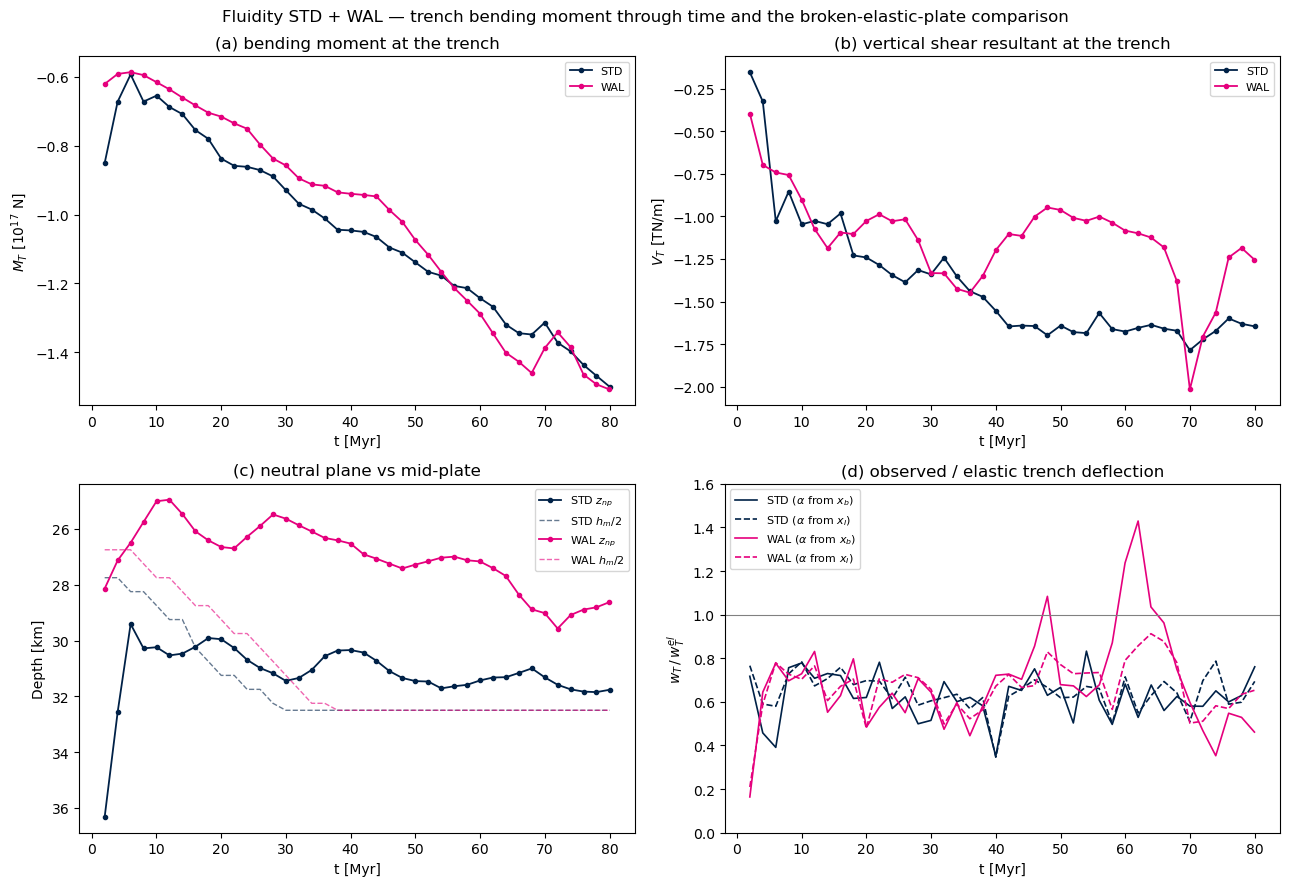

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for key, ts in series.items():
    c = MCOL[key]; g = ts["good"]
    t = ts["t_myr"]
    axes[0, 0].plot(t[g], ts["M"][g] * 1e-17, ".-", color=c, lw=1.3, label=key)
    axes[0, 1].plot(t[g], ts["V_T"][g] * 1e-12, ".-", color=c, lw=1.3, label=key)
    axes[1, 0].plot(t[g], ts["z_np"][g] / 1e3, ".-", color=c, lw=1.3, label=f"{key} $z_{{np}}$")
    axes[1, 0].plot(t[g], ts["h_m"][g] / 2e3, "--", color=c, lw=1.0, alpha=0.6,
                    label=f"{key} $h_m/2$")
    gm = g & np.isfinite(ts["w_el_b"]) & np.isfinite(ts["w_el_0"])
    axes[1, 1].plot(t[gm], ts["w_T"][gm] / ts["w_el_b"][gm], "-", color=c, lw=1.2,
                    label=f"{key} ($\\alpha$ from $x_b$)")
    axes[1, 1].plot(t[gm], ts["w_T"][gm] / ts["w_el_0"][gm], "--", color=c, lw=1.2,
                    label=f"{key} ($\\alpha$ from $x_I$)")
axes[0, 0].set_ylabel(r"$M_T$ [$10^{17}$ N]")
axes[0, 0].set_title("(a) bending moment at the trench")
axes[0, 1].set_ylabel(r"$V_T$ [TN/m]")
axes[0, 1].set_title("(b) vertical shear resultant at the trench")
axes[1, 0].invert_yaxis()
axes[1, 0].set_ylabel("Depth [km]")
axes[1, 0].set_title("(c) neutral plane vs mid-plate")
axes[1, 1].axhline(1.0, color="0.5", lw=0.8)
axes[1, 1].set_ylabel(r"$w_T\,/\,w_T^{el}$")
axes[1, 1].set_ylim(0, 1.6)
axes[1, 1].set_title("(d) observed / elastic trench deflection")
for ax in axes.flat:
    ax.set_xlabel("t [Myr]")
    ax.legend(fontsize=8)
fig.suptitle("Fluidity STD + WAL — trench bending moment through time and the "
             "broken-elastic-plate comparison", fontsize=12)
fig.tight_layout()
out = figures_dir / "bending_moment_time_series.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print("figure:", out)

**Interpretation**

- **$|M_T|$ grows monotonically** in both models — WAL from $0.6$ to $1.5 \times 10^{17}$ N over 80 Myr, STD similarly — in contrast to the MDOODZ forced model where $M_T$ is flat. The free slab keeps loading the plate as it lengthens; the trench bending moment is a *live* quantity here, not a constant of the setup.
- **The vertical load is real**: $V_T \approx -1$ to $-2$ TN/m throughout, versus $\approx 0$ in MDOODZ. The Fluidity trench is supported by both resultants; the $V\alpha$ term carries a substantial share of the elastic prediction rather than the few percent it contributes in MDOODZ (share printed in §3).
- **The neutral plane is stable and mid-plate** (WAL ~25–30 km, STD ~30–32 km) — but late in the run $h_m/2$ keeps deepening thermally (to ~32.5 km) while $z_{np}$ stops following, most visibly in WAL: the *mechanical* mid-plate decouples from the thermal one as the plate ages, and — reassuringly for the legacy analysis — the robust and first-crossing picks coincide in every snapshot but one (a single STD step carries a second crossing, which the robust picker resolves without intervention).
- **The elastic ratio sits at ~0.6–0.7 and the two $\alpha$ calibrations agree** (STD 0.62 / 0.65, WAL 0.66 / 0.68, forebulge vs first-zero) — unlike MDOODZ, where the calibrations split (0.66 vs 0.96). The Fluidity profiles are close to elastic in *shape* (the two length scales are mutually consistent, as is $V = dM/dx$ at corr +0.79), which makes the amplitude deficit robust: the trench is systematically about **2/3 as deep** as a broken elastic plate carrying the measured $(V, M)$. Distributed inelastic yielding relaxing the surface expression is the natural reading. WAL forebulge-pick excursions near $t \approx 60$ Myr push single snapshots above 1.
- Honesty box: neutral-plane search 5–60 km; base 950 °C capped at 65 km; time loop on the 1 km grid (single-step numbers on the 200 m grid differ at the few-percent level); $t = 0$ excluded (no formed trench); forebulge picks in WAL are the dominant noise source in panel (d).

**Next**: put all three codes on one $w_T$-vs-$(V, M)$ figure, and track effective $\alpha$ (or $T_e$) against the thermal thickness to separate geometric weakening from thermal ageing.